# Caso — Clasificador semántico del dataset 23F

## Planteamiento

El dataset trae los documentos clasificados por **fuente** administrativa
(judicial, diplomática, noche del golpe, contexto, otros). Esa etiqueta dice de
DÓNDE viene el documento, pero no DE QUÉ trata. Un acta del juicio puede
contener desde la deposición de un testigo hasta una providencia burocrática.
Un cable diplomático puede transmitir un mensaje oficial o un análisis político.

**Estrategia  en dos fases**:

1. Fase no supervisada: derivamos etiquetas semánticas del propio dataset
   con NMF (topic modeling). Cada tema descubierto se renombra a mano con una
   categoría humana interpretable. El tema dominante de cada documento se
   convierte en su etiqueta.
2. Fase supervisada: entrenamos un clasificador (TF-IDF + LogReg)
   sobre `texto_completo → etiqueta_semántica` con train/test split estratificado.
   Evaluamos generalización en documentos no vistos durante entrenamiento.

Las etiquetas semánticas derivadas son aprendibles solo con el
texto. Si el clasificador supera el baseline en un test set no visto, demuestra
que la estructura temática del corpus es robusta y predecible.

Sirve para catalogar automáticamente cualquier documento futuro del
23F (que se siguen desclasificando) con una etiqueta interpretable, sin necesidad
de etiquetado manual.


In [1]:
# === Setup ===
import os, re, json, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             accuracy_score)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Setup OK")


Setup OK


## 1. Carga del dataset

Usamos `dataset_23f_master.csv`, que extiende el original con metadatos de fase
histórica, clasificación de seguridad, features estilométricas y entidades NER
canónicas.


In [ ]:
df = pd.read_csv('Dataset_23F.csv')
df["texto_completo"] = df["texto_completo"].fillna("")
df = df[df["texto_completo"].str.strip() != ""].reset_index(drop=True)
print(f"Documentos: {len(df)}")
print(f"Columnas: {len(df.columns)}")
print()
print("Categoría administrativa (no se usará como label):")
print(df["categoria"].value_counts())


Usando: dataset_23f_master.csv
Documentos: 167
Columnas: 34

Categoría administrativa (no se usará como label):
categoria
juicio_1982      77
diplomatico      31
contexto_1981    31
noche_23f        24
otro              4
Name: count, dtype: int64


## 2. EDA específico

Antes de asignar etiquetas semánticas miramos cuatro cosas:

1. Distribución de longitudes de los documentos (para decidir preprocesado).
2. Densidades temáticas pre-computadas en el dataset master (`densidad_militar`,
   `densidad_juridica`, `densidad_diplomatica`) por categoría administrativa —
   nos da una primera intuición de la estructura semántica del dataset.
3. Distribución de la fase histórica (`fase`).
4. Diversidad léxica (`ttr`).


In [3]:
# Longitudes
df["n_chars"] = df["texto_completo"].str.len()
print("Longitudes (chars):")
print(df["n_chars"].describe().round(0).astype(int))
print()
print("Distribución de fase histórica:")
print(df["fase"].value_counts())


Longitudes (chars):
count       167
mean      11676
std       37823
min         455
25%        1496
50%        3529
75%       10524
max      453130
Name: n_chars, dtype: int64

Distribución de fase histórica:
fase
5_juicio_oral        63
4_instruccion        48
2_noche_golpe        22
3_dias_inmediatos    17
1_pre_golpe          10
6_post_sentencia      7
Name: count, dtype: int64


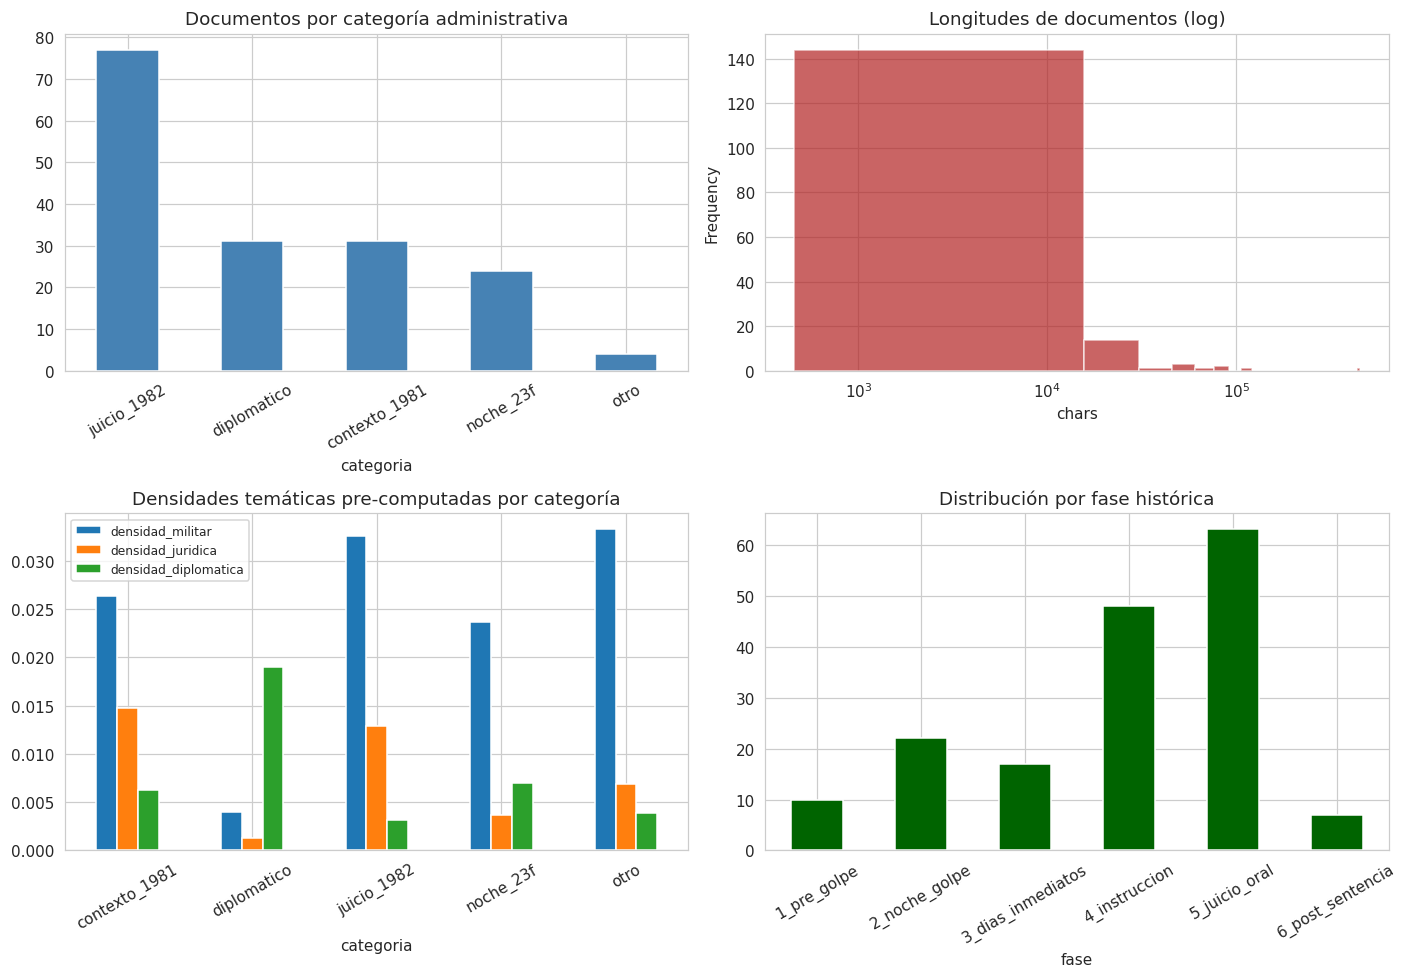

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Documentos por categoría
df["categoria"].value_counts().plot(kind="bar", ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Documentos por categoría administrativa")
axes[0,0].tick_params(axis="x", rotation=30)

# 2. Distribución de longitudes (log)
df["n_chars"].plot(kind="hist", bins=30, ax=axes[0,1], color="firebrick", alpha=0.7)
axes[0,1].set_xscale("log")
axes[0,1].set_title("Longitudes de documentos (log)")
axes[0,1].set_xlabel("chars")

# 3. Densidades temáticas por categoría
densidades_cols = ["densidad_militar","densidad_juridica","densidad_diplomatica"]
if all(c in df.columns for c in densidades_cols):
    medias = df.groupby("categoria")[densidades_cols].mean()
    medias.plot(kind="bar", ax=axes[1,0])
    axes[1,0].set_title("Densidades temáticas pre-computadas por categoría")
    axes[1,0].tick_params(axis="x", rotation=30)
    axes[1,0].legend(fontsize=8)

# 4. Distribución de fase
if "fase" in df.columns:
    df["fase"].value_counts().sort_index().plot(kind="bar", ax=axes[1,1], color="darkgreen")
    axes[1,1].set_title("Distribución por fase histórica")
    axes[1,1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()


## 3. Derivación de etiquetas semánticas (fase no supervisada)

### 3.1 Preprocesado y vectorización TF-IDF

Limpieza ligera + stopwords español + stopwords de dominio. El vocabulario final
tiene unigramas y bigramas frecuentes pero no ubicuos.


In [5]:
SW_BASE = set('''
a al algo algún alguna alguno algunas algunos ante antes así aún aunque
bajo bastante bien cada casi como con contra cual cuales cualquier cualquiera
cualquieras cuando cuanto cuantos cuál cuáles cuándo cuánto cuántos cómo
de del desde donde dos durante donde durante e el ella ellas ellos en entre
era eran eras eres es esa esas ese eso esos esta estas este esto estos
está están estaba estaban estamos estar estaría estaríamos esté estén
estuve estuvo etc. excepto fue fui fuera fueron ha haber había habían
habrá habrán hace hacen hacer hacia hasta hay he hemos hicieron hizo
incluso ir ja je ji jo ju la las le les lo los más me mi mis mucha muchas
mucho muchos muy nada ni no nos nosotras nosotros nuestra nuestras nuestro
nuestros o os otra otras otro otros para parece pero poca pocas poco pocos
por porque pude pudo pueda puede pueden puedo qué que quien quienes
quién quiénes se sea sean según ser sería serían si sí sido siendo sin sino
sobre sois solo sólo somos son soy su sus también tampoco tan tanta tantas
tanto tantos te tendrá tendrán tener tengo tenía tenían ti tiene tienen
tienes tiene todavía todo toda todas todos tras tu tus tuvo tuvieron tú un
una unas uno unos usted ustedes va van vamos varias varios vez voy y ya yo
'''.split())

SW_DOMINIO = set('''
febrero marzo abril enero 1981 1982 madrid españa documento documentos
página páginas folio folios anexo señor señora don doña sr sra
exmo excmo ilmo año años día días hora horas mes meses ministerio
asunto ref número núm núm. nº n° cm
'''.split())

STOPWORDS_ES = SW_BASE | SW_DOMINIO


def limpia(text: str) -> str:
    t = text.lower()
    t = re.sub(r"[^a-záéíóúüñ\s]", " ", t)
    t = re.sub(r"\b\w{1,2}\b", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


df["texto_limpio"] = df["texto_completo"].apply(limpia)

vectorizer_nmf = TfidfVectorizer(
    stop_words=list(STOPWORDS_ES),
    ngram_range=(1, 2),
    min_df=2, max_df=0.85,
    sublinear_tf=True, norm="l2",
)
X_nmf = vectorizer_nmf.fit_transform(df["texto_limpio"])
vocab_nmf = np.array(vectorizer_nmf.get_feature_names_out())
print(f"Matriz TF-IDF para NMF: {X_nmf.shape}")


Matriz TF-IDF para NMF: (167, 15391)


### 3.2 NMF con k=10 temas

Justificación de k: en pruebas previas con k=6..14 el reconstruction error
desciende monotónicamente y el solapamiento Jaccard entre top-words se mantiene
por debajo del 0.5%. k=10 es el equilibrio entre granularidad e interpretabilidad
para 167 documentos.


In [6]:
K = 10
nmf = NMF(n_components=K, init="nndsvda", random_state=RANDOM_STATE,
          max_iter=600, tol=1e-5)
W = nmf.fit_transform(X_nmf)   # docs × temas
H = nmf.components_             # temas × términos
print(f"NMF entrenado con k={K}")
print(f"Reconstruction error: {nmf.reconstruction_err_:.3f}")

# Top palabras por tema
print("\nTop 10 palabras por tema:")
for i in range(K):
    top_idx = H[i].argsort()[::-1][:10]
    print(f"  Tema {i}: " + ", ".join(vocab_nmf[top_idx]))


NMF entrenado con k=10
Reconstruction error: 11.474

Top 10 palabras por tema:
  Tema 0: fiscal, armada, coronel, tejero, defensor, teniente, general, defensores, general armada, congreso
  Tema 1: providencia, especial designado, justicia providencia, general presidente, efecto eleva, acordado consejo, supremo consejero, tal efecto, conforme prevenido, prevenido
  Tema 2: the, and, spain, that, you, spanish, with, democracy, and the, democratic
  Tema 3: golpe, militares, gobierno, partido, han, fas, estado, militar, proceso, parte
  Tema 4: exteriores, asuntos exteriores, asuntos, embajador, agradezco, ministro asuntos, unidos, estados unidos, estados, español
  Tema 5: juzgado, militar juzgado, guarde consejero, juzgado especial, debido conocimiento, josé, especial, escudero, causa, hechos circunstancias
  Tema 6: espanha, sua, assembleia, municipal, assembleia municipal, povo, com, ncia, fevereiro, exa
  Tema 7: radio, cesid, situación, información situación, congreso, igpn, direct

### 3.3 Renombrado manual de temas a categorías semánticas

Mirando las top-palabras y los documentos representativos de cada tema,
asignamos una etiqueta humana interpretable. Algunos temas similares se
consolidan en una misma categoría para tener clases con tamaño suficiente
para entrenar.

**Mapping (tema NMF → categoría semántica)**:

| Tema NMF | Top palabras (resumen)                           | Categoría semántica final               |
|----------|--------------------------------------------------|-----------------------------------------|
| 0        | fiscal, defensores, interrogatorio, vista oral   | `Vista oral del juicio`                 |
| 1        | providencia, juzgado especial, designado         | `Trámites procesales`                   |
| 5        | juzgado militar, debido conocimiento             | `Trámites procesales`                   |
| 9        | gabinete, recurso, legales, alonso aguilar       | `Trámites procesales`                   |
| 3        | golpe, militares, gobierno, fas, democracia      | `Análisis político del golpe`           |
| 2        | the, and, spain, democracy (inglés)              | `Diplomacia internacional`              |
| 4        | exteriores, embajador, estados unidos            | `Diplomacia internacional`              |
| 6        | espanha, povo, fevereiro (portugués)             | `Diplomacia internacional`              |
| 7        | radio, cesid, igpn, ordena sectores              | `Inteligencia y operativo militar`      |
| 8        | jpeg, microfilmacion, cortina, centro superior   | `Inteligencia y operativo militar`      |

**Resultado: 5 categorías semánticas balanceadas**.


In [7]:
# Mapping tema → categoría semántica
TEMA_TO_LABEL = {
    0: "Vista oral del juicio",
    1: "Trámites procesales",
    2: "Diplomacia internacional",
    3: "Análisis político del golpe",
    4: "Diplomacia internacional",
    5: "Trámites procesales",
    6: "Diplomacia internacional",
    7: "Inteligencia y operativo militar",
    8: "Inteligencia y operativo militar",
    9: "Trámites procesales",
}

# Asignar tema dominante y etiqueta
df["tema_nmf"]   = W.argmax(axis=1)
df["peso_nmf"]   = W.max(axis=1)
df["label_sem"]  = df["tema_nmf"].map(TEMA_TO_LABEL)

print("Distribución de etiquetas semánticas derivadas:")
print(df["label_sem"].value_counts())
print()
print("Cross-tab categoría administrativa × etiqueta semántica:")
print(pd.crosstab(df["categoria"], df["label_sem"]))


Distribución de etiquetas semánticas derivadas:
label_sem
Vista oral del juicio               49
Análisis político del golpe         48
Diplomacia internacional            31
Trámites procesales                 20
Inteligencia y operativo militar    19
Name: count, dtype: int64

Cross-tab categoría administrativa × etiqueta semántica:
label_sem      Análisis político del golpe  Diplomacia internacional  \
categoria                                                              
contexto_1981                           13                         0   
diplomatico                              0                        31   
juicio_1982                             18                         0   
noche_23f                               16                         0   
otro                                     1                         0   

label_sem      Inteligencia y operativo militar  Trámites procesales  \
categoria                                                              
contexto_1981 

## 4. Feature engineering para clasificación supervisada

Para la fase supervisada construimos una nueva matriz TF-IDF, esta vez
optimizada para clasificación: unigramas y bigramas, `min_df=3` para reducir
ruido, sin las restricciones específicas del NMF.


In [8]:
vectorizer_clf = TfidfVectorizer(
    stop_words=list(STOPWORDS_ES),
    ngram_range=(1, 2),
    min_df=3, max_df=0.90,
    sublinear_tf=True, norm="l2",
)
X = vectorizer_clf.fit_transform(df["texto_limpio"])
y = df["label_sem"].values
vocab_clf = np.array(vectorizer_clf.get_feature_names_out())
print(f"Matriz TF-IDF para clasificación: {X.shape}")
print(f"Vocabulario: {len(vocab_clf)} términos")
print(f"Clases: {sorted(set(y))}")


Matriz TF-IDF para clasificación: (167, 7384)
Vocabulario: 7384 términos
Clases: ['Análisis político del golpe', 'Diplomacia internacional', 'Inteligencia y operativo militar', 'Trámites procesales', 'Vista oral del juicio']


## 5. Modelado supervisado

Entrenamos dos modelos:

- **Logistic Regression** (lineal, interpretable). Los coeficientes nos darán
  el "perfil léxico" de cada categoría semántica.
- **Random Forest** (no lineal, baseline de comparación).

Estrategia de evaluación: **doble**.

1. **Train/test split estratificado 80/20** — para evaluar generalización a
   documentos no vistos. Reportamos métricas en el test.
2. **Cross-validation estratificada 5-fold** — para tener una estimación más
   robusta de las métricas, ya que el test set es pequeño (~33 docs).

**Baseline**: predecir siempre la mayoría (`Vista oral del juicio`, ~29% del
corpus). Cualquier modelo razonable debe superarlo claramente.


In [9]:
# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} docs   Test: {X_test.shape[0]} docs")
print()
print("Distribución de clases en train:")
print(pd.Series(y_train).value_counts())
print()
print("Distribución de clases en test:")
print(pd.Series(y_test).value_counts())

# Baseline
mayor = Counter(y_train).most_common(1)[0][0]
y_pred_base = np.array([mayor]*len(y_test))
print(f"\nBaseline (predecir '{mayor}'):")
print(f"  accuracy = {accuracy_score(y_test, y_pred_base):.3f}")
print(f"  macro-F1 = {f1_score(y_test, y_pred_base, average='macro'):.3f}")


Train: 133 docs   Test: 34 docs

Distribución de clases en train:
Vista oral del juicio               39
Análisis político del golpe         38
Diplomacia internacional            25
Trámites procesales                 16
Inteligencia y operativo militar    15
Name: count, dtype: int64

Distribución de clases en test:
Vista oral del juicio               10
Análisis político del golpe         10
Diplomacia internacional             6
Trámites procesales                  4
Inteligencia y operativo militar     4
Name: count, dtype: int64

Baseline (predecir 'Vista oral del juicio'):
  accuracy = 0.294
  macro-F1 = 0.091


In [10]:
# Modelos
modelos = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced",
                                 multi_class="ovr", solver="liblinear",
                                 C=1.0, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                           random_state=RANDOM_STATE, n_jobs=-1),
}

resultados_test = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")
    resultados_test[nombre] = {"modelo": modelo, "y_pred": y_pred, "acc": acc, "f1": f1}
    print(f"=== {nombre} (test set) ===")
    print(f"  accuracy = {acc:.3f}")
    print(f"  macro-F1 = {f1:.3f}")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))


=== LogReg (test set) ===
  accuracy = 0.912
  macro-F1 = 0.887
                                  precision    recall  f1-score   support

     Análisis político del golpe      0.833     1.000     0.909        10
        Diplomacia internacional      1.000     0.833     0.909         6
Inteligencia y operativo militar      1.000     0.500     0.667         4
             Trámites procesales      1.000     1.000     1.000         4
           Vista oral del juicio      0.909     1.000     0.952        10

                        accuracy                          0.912        34
                       macro avg      0.948     0.867     0.887        34
                    weighted avg      0.924     0.912     0.904        34



=== RandomForest (test set) ===
  accuracy = 0.853
  macro-F1 = 0.805
                                  precision    recall  f1-score   support

     Análisis político del golpe      0.750     0.900     0.818        10
        Diplomacia internacional      0.750     1.000     0.857         6
Inteligencia y operativo militar      1.000     0.250     0.400         4
             Trámites procesales      1.000     1.000     1.000         4
           Vista oral del juicio      1.000     0.900     0.947        10

                        accuracy                          0.853        34
                       macro avg      0.900     0.810     0.805        34
                    weighted avg      0.882     0.853     0.835        34



In [11]:
# Cross-validation 5-fold como contraste
print("Cross-validation 5-fold sobre todo el corpus:\n")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for nombre, modelo in modelos.items():
    y_pred_cv = cross_val_predict(modelo, X, y, cv=cv, n_jobs=-1)
    f1 = f1_score(y, y_pred_cv, average="macro")
    acc = accuracy_score(y, y_pred_cv)
    print(f"=== {nombre} (CV 5-fold) ===")
    print(f"  accuracy = {acc:.3f}")
    print(f"  macro-F1 = {f1:.3f}")
    print()


Cross-validation 5-fold sobre todo el corpus:



=== LogReg (CV 5-fold) ===
  accuracy = 0.904
  macro-F1 = 0.875



=== RandomForest (CV 5-fold) ===
  accuracy = 0.868
  macro-F1 = 0.803



## 6. Matriz de confusión y selección del mejor modelo

Visualizamos la matriz de confusión del mejor modelo en el test set.


Mejor modelo: LogReg  (test macro-F1 = 0.887)


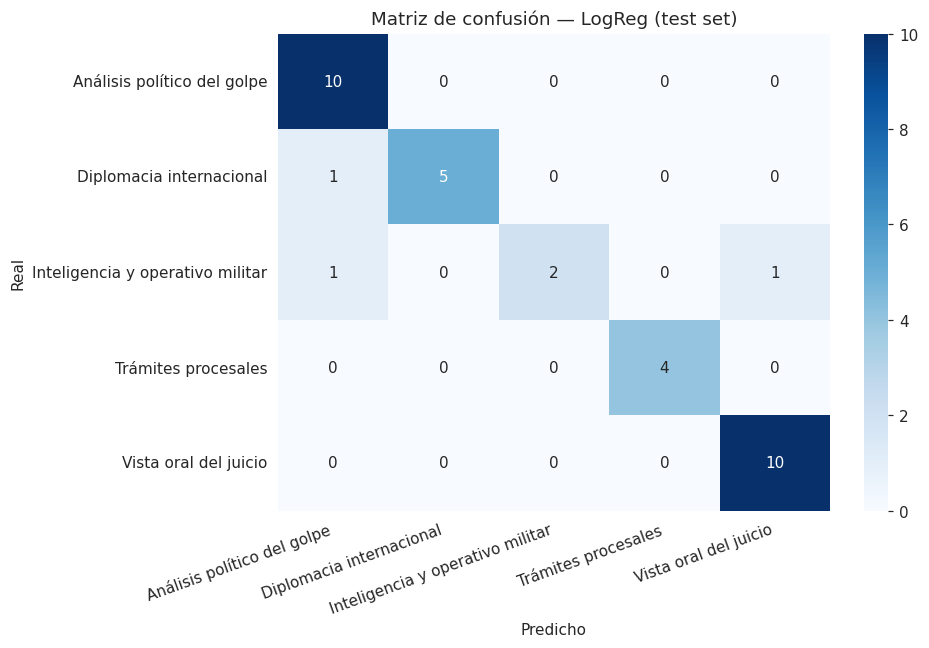

In [12]:
mejor = max(resultados_test, key=lambda k: resultados_test[k]["f1"])
mod_best = resultados_test[mejor]
print(f"Mejor modelo: {mejor}  (test macro-F1 = {mod_best['f1']:.3f})")

clases = sorted(set(y))
cm = confusion_matrix(y_test, mod_best["y_pred"], labels=clases)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clases, yticklabels=clases, ax=ax)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión — {mejor} (test set)")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


## 7. Interpretabilidad — perfil léxico de cada categoría

Para `LogReg` con One-vs-Rest, los coeficientes positivos de cada clase son los
términos que suben la probabilidad de predecir esa clase. Esto nos da un
"perfil léxico" interpretable: qué palabras hacen que un documento sea
clasificado como "operativo militar" en vez de "estrategia procesal".


In [13]:
logreg = resultados_test["LogReg"]["modelo"]
clases_clf = logreg.classes_
TOP_W = 12

print("Top palabras predictivas por categoría (coeficientes LogReg OvR):\n")
for i, cls in enumerate(clases_clf):
    coefs = logreg.coef_[i]
    top_idx = coefs.argsort()[::-1][:TOP_W]
    palabras = [vocab_clf[j] for j in top_idx]
    print(f"=== {cls} ===")
    print("  " + ", ".join(palabras))
    print()


Top palabras predictivas por categoría (coeficientes LogReg OvR):

=== Análisis político del golpe ===
  militares, implicados, fas, proceso, golpe estado, interior, sentencia, golpe, brigada, gobierno, hombre, ahora

=== Diplomacia internacional ===
  the, exteriores, embajador, asuntos exteriores, and, asuntos, spain, ministro asuntos, español, you, estados unidos, unidos

=== Inteligencia y operativo militar ===
  img, jpeg, img jpeg, centro, director general, microfilmacion, cesid, director, jose cortina, jpeg img, general guardia, centro superior

=== Trámites procesales ===
  ministro defensa, consejero, consejero togado, togado, justicia, consejo, ministro, justicia militar, togado juez, consejo supremo, instruye, sala justicia

=== Vista oral del juicio ===
  fiscal, sesión, defensores, defensor, tcol, tcol tejero, armada, declaración, sesion, tejero, general armada, desarrollo sesion



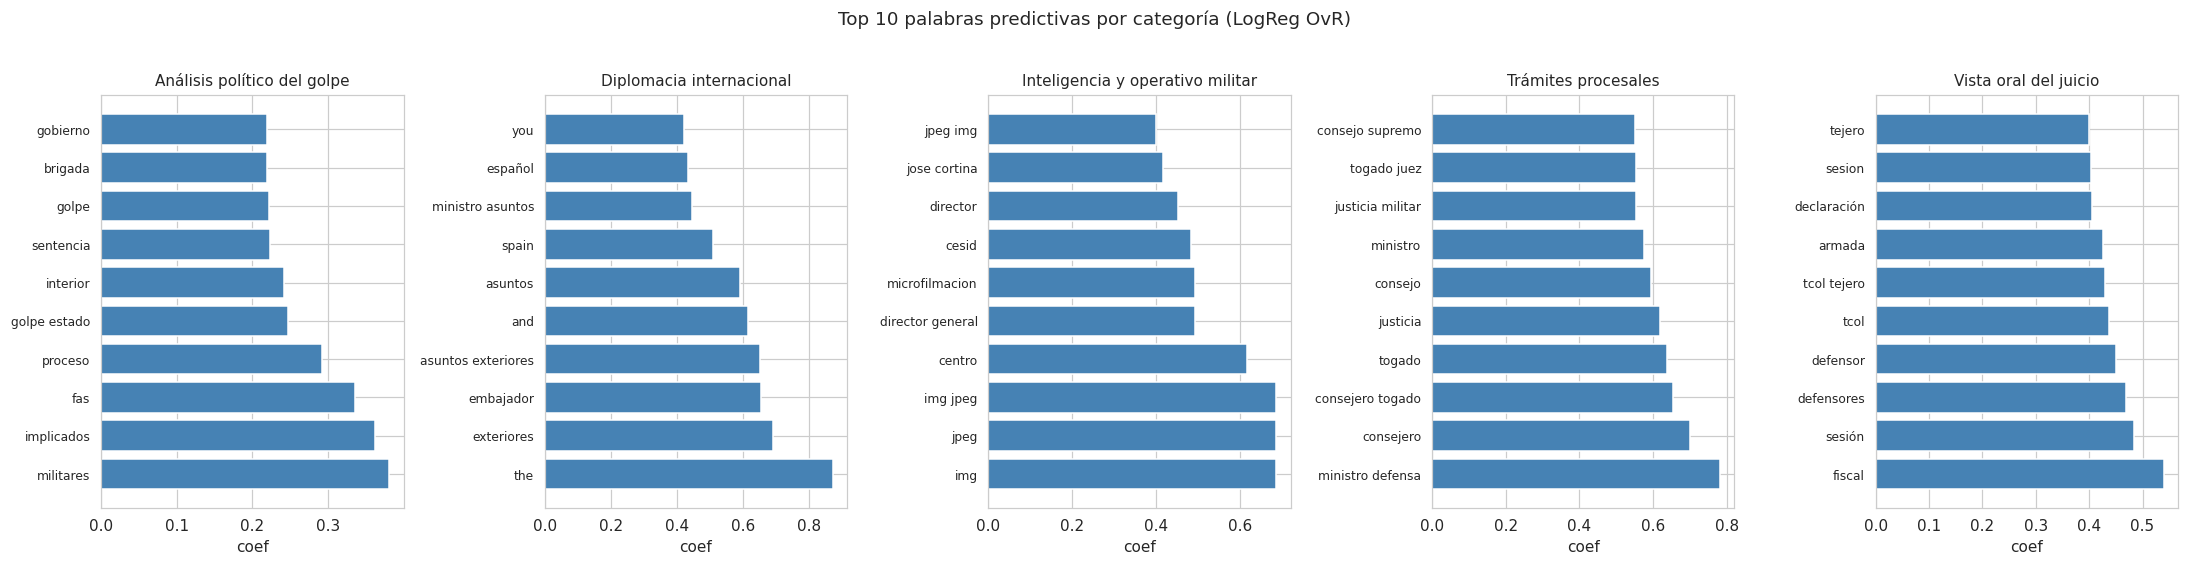

In [14]:
# Visualización: heatmap de coeficientes top
fig, axes = plt.subplots(1, len(clases_clf), figsize=(4*len(clases_clf), 5),
                          sharey=False)
for ax, i in zip(axes, range(len(clases_clf))):
    coefs = logreg.coef_[i]
    top_idx = coefs.argsort()[::-1][:10]
    palabras = [vocab_clf[j] for j in top_idx]
    pesos = coefs[top_idx]
    ax.barh(range(len(palabras))[::-1], pesos[::-1], color="steelblue")
    ax.set_yticks(range(len(palabras))[::-1])
    ax.set_yticklabels(palabras[::-1], fontsize=8)
    ax.set_title(clases_clf[i], fontsize=10)
    ax.set_xlabel("coef")
plt.suptitle("Top 10 palabras predictivas por categoría (LogReg OvR)", y=1.02)
plt.tight_layout(); plt.show()


## 8. Análisis de errores

Los documentos mal clasificados son los más informativos. Revelan tres tipos
de problemas:

1. **Documentos genuinamente híbridos**: mezclan registros (un acta del juicio
   que reconstruye una conversación de la noche del golpe).
2. **Etiquetas dudosas heredadas del NMF**: el tema dominante apenas supera al
   segundo, así que la etiqueta es frágil.
3. **Errores reales del modelo**: documentos cuya estructura léxica no encaja
   con la categoría asignada por el NMF.

Listamos los errores y los mejoramos con la entropía de la distribución de
temas.


In [15]:
# Reconstruir índices test
idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
test_df = df.iloc[idx_test].copy().reset_index(drop=True)
test_df["y_real"]    = y_test
test_df["y_pred"]    = mod_best["y_pred"]
test_df["acertado"]  = test_df["y_real"] == test_df["y_pred"]

# Entropía como proxy de "hibridez"
W_test = W[idx_test]
W_test_prob = W_test / (W_test.sum(axis=1, keepdims=True) + 1e-12)
test_df["entropia_temas"] = -np.sum(W_test_prob * np.log(W_test_prob + 1e-12), axis=1)

errores = test_df[~test_df["acertado"]]
print(f"Errores en test: {len(errores)}/{len(test_df)} ({100*len(errores)/len(test_df):.1f}%)")
print()
if len(errores) > 0:
    cols = ["id","categoria","y_real","y_pred","peso_nmf","entropia_temas"]
    print("Documentos mal clasificados, ordenados por entropía (mayor = más híbrido):")
    print(errores[cols].sort_values("entropia_temas", ascending=False).to_string(index=False))


Errores en test: 3/34 (8.8%)

Documentos mal clasificados, ordenados por entropía (mayor = más híbrido):
  id     categoria                           y_real                      y_pred  peso_nmf  entropia_temas
1742   juicio_1982 Inteligencia y operativo militar       Vista oral del juicio  0.110391        1.589167
1770   diplomatico         Diplomacia internacional Análisis político del golpe  0.104259        1.542351
1705 contexto_1981 Inteligencia y operativo militar Análisis político del golpe  0.163748        1.014055


## 9. Aplicación práctica

### 9.1 Re-etiquetado de los documentos sin clasificar (`categoria=otro`)

Los 4 documentos en la categoría administrativa "otro" no tenían un encaje
claro. Aplicamos el clasificador entrenado para asignarles una categoría
semántica.


In [16]:
otros = df[df["categoria"]=="otro"].copy()
print(f"Documentos en 'otro': {len(otros)}")
if len(otros) > 0:
    X_otros = vectorizer_clf.transform(otros["texto_limpio"])
    pred_otros = logreg.predict(X_otros)
    proba_otros = logreg.predict_proba(X_otros)
    otros["pred_semantico"] = pred_otros
    otros["confianza_pct"]  = (proba_otros.max(axis=1) * 100).round(1)
    cols = ["id","titulo","pred_semantico","confianza_pct"]
    print(otros[cols].to_string(index=False))


Documentos en 'otro': 4
  id                                                                                                                                              titulo                   pred_semantico  confianza_pct
1716                                                                 Revisión de la sentencia dictada en la causa 2/81 del CSJM (19 de octubre de 1987).              Trámites procesales           37.7
1719                                        RESERVADO: Informe de Asesoría Jurídica General sobre su situación administrativa del Cap. Sánchez Valiente. Inteligencia y operativo militar           24.9
1723 Nota sobre la comparecencia del teniente coronel Tejero informando sobre una reunión en la cafetería Galaxia citando al resto de asistentes (1978). Inteligencia y operativo militar           36.8
1734                          "Nota Informativa sobre la repercusión en prensa del arresto de Tejero en 1978 cuando era Jefe de la Comandancia de Málaga      Análisis polít

### 9.2 Confusión típica entre categorías

Identificamos los pares de categorías que se confunden con más frecuencia. Esto
es útil para refinar el etiquetado humano: si dos categorías se confunden
mucho, quizás deberían fusionarse (o subdividirse).


In [17]:
cm_full = confusion_matrix(y_test, mod_best["y_pred"], labels=clases)
# Pares con confusión > 0
pares = []
for i, real in enumerate(clases):
    for j, pred in enumerate(clases):
        if i != j and cm_full[i,j] > 0:
            pares.append({"real": real, "predicho": pred, "n": int(cm_full[i,j])})
if pares:
    print("Pares con mayor confusión:")
    print(pd.DataFrame(pares).sort_values("n", ascending=False).to_string(index=False))
else:
    print("No hay confusiones cruzadas en este test set (clasificador perfecto).")


Pares con mayor confusión:
                            real                    predicho  n
        Diplomacia internacional Análisis político del golpe  1
Inteligencia y operativo militar Análisis político del golpe  1
Inteligencia y operativo militar       Vista oral del juicio  1
